In [4]:
import uproot
import coffea
from coffea import hist, processor
import numpy as np

# Open a ROOT file
# file_path = "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Hcal_R000398187.root"
# file_path = "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_SiStrip_R000398191.root"
file_path =  "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398185.root"

 # "/eos/uscms/store/user/kkwok/DQM/DQM_V0001_PixelGPU_R000398187.root"
file = uproot.open(file_path)

# List the keys in the ROOT file
print("Keys in the ROOT file:")
allkeys=[]
for key in file.keys():
    print(key)
    allkeys.append(key)

# Example: Access a specific branch (replace 'branch_name' with actual branch name)
# branch_name = "your_branch_name"
# if branch_name in file:
#     branch_data = file[branch_name].array()
#     print(f"Data from branch '{branch_name}':")
#     print(branch_data)

Keys in the ROOT file:
DQMData;1
DQMData/Run 398185;1
DQMData/Run 398185/L1T;1
DQMData/Run 398185/L1T/Run summary;1
DQMData/Run 398185/L1T/Run summary/EventInfo;1
DQMData/Run 398185/L1T/Run summary/EventInfo/<reportSummary>f=0.9369814395904541</reportSummary>;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryMap;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryContents;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryContents/<L1T_L1Obj_Mu_muon_PtRange>f=1</L1T_L1Obj_Mu_muon_PtRange>;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryContents/<L1T_L1Obj_Mu_muon_etaMeanAt0>f=1</L1T_L1Obj_Mu_muon_etaMeanAt0>;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryContents/<L1T_L1Obj_Mu_muon_phiMeanAt0>f=1</L1T_L1Obj_Mu_muon_phiMeanAt0>;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryContents/<L1T_L1Obj_Mu_muon_phiSpectrum>f=0</L1T_L1Obj_Mu_muon_phiSpectrum>;1
DQMData/Run 398185/L1T/Run summary/EventInfo/reportSummaryContents/<L1T_L

In [5]:
l = [k for k in allkeys if "ecalOcc" in k]
print(len(l))
l

20


['DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ecalOccRecdEtWgt;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ecalOccupancy;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccEtDiscrepancy;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccFgDiscrepancy;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccLinkMasked;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccRecd5Bx;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccRecd5BxEtWgt;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccRecdBx1;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccRecdBx2;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccRecdBx3;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ECalDetail/ecalOccRecdBx4;1',
 'DQMData/Run 398185/L1T/Run summary/L1TStag

In [7]:
h = file['DQMData/Run 398185/L1T/Run summary/L1TStage2CaloLayer1/ecalOccRecdEtWgt'].to_hist()

In [8]:
h

Hist(
  Regular(57, -28.5, 28.5, name='xaxis', label='iEta'),
  Regular(72, 0.5, 72.5, name='yaxis', label='iPhi'),
  storage=Weight()) # Sum: WeightedSum(value=9.23744e+07, variance=9.30513e+08)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd4c47ab5e0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd4c482c940>, text=[])

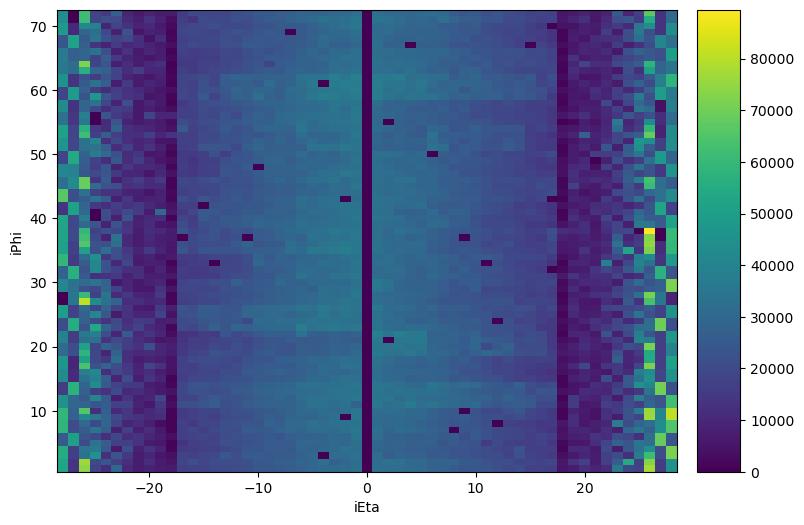

In [10]:
import mplhep
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(8, 6))
mplhep.hist2dplot(h, ax=axs,)
# mplhep.histplot(h, ax=axs,)

# axs.set_xlim(0,100)

# ROOT plotting

TypeError: unsupported format string passed to boost_histogram._core.accumulators.WeightedSum.__format__

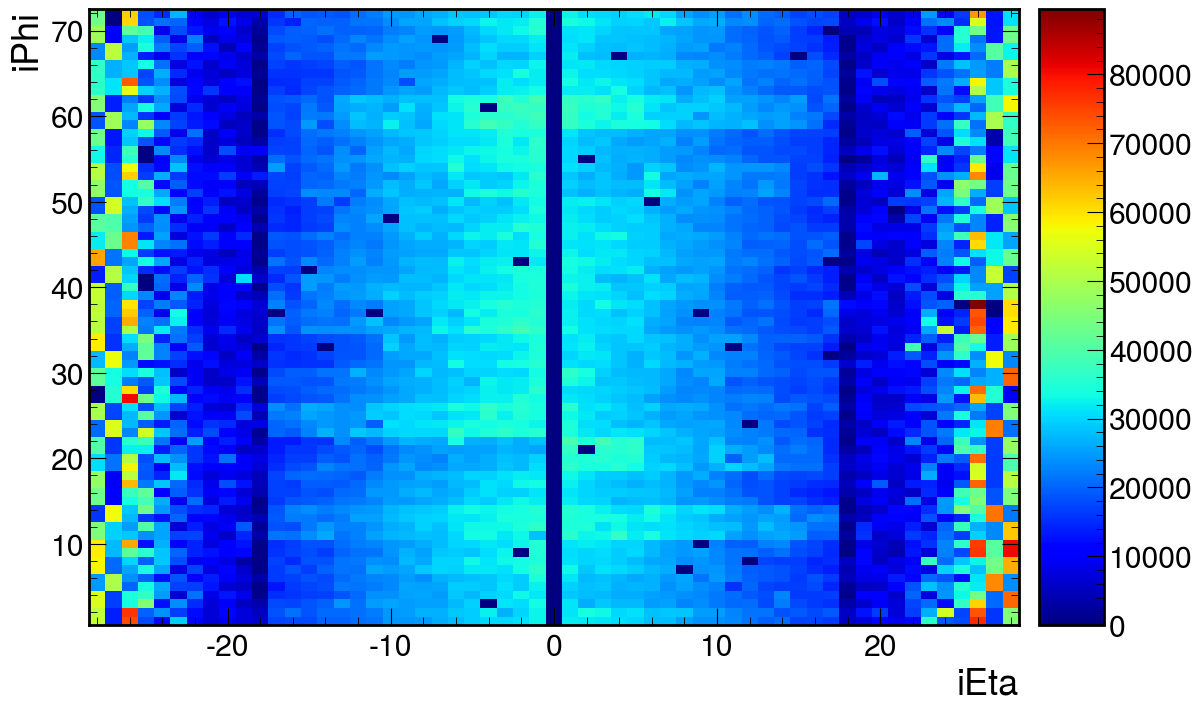

In [20]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

fig, ax = plt.subplots(figsize=(12, 8))

hep.hist2dplot(
    h,
    ax=ax,
    cmap="jet",          # ROOT rainbow; swap "turbo" for a cleaner look
    # vmin=0,
    # vmax=360,
    cbarextend=True,     # adds arrow when cells are clipped above vmax
)

# hep.cms.label(
#     ax=ax,
#     label="",
#     data=True,
#     lumi=None,
#     rlabel="FNAL ROC",
# )

# ax.set_title(
#     "ECal TP ET-weighted Occupancy at Layer1",
#     loc="left", fontsize=13, fontweight="bold",
# )

plt.tight_layout()
plt.savefig("ecal_occ.png", dpi=150, bbox_inches="tight")

In [32]:
import re

# Method 1: Using regular expressions (most robust)
def extract_run_numbers_regex(filename):
    # Pattern to match 6 or more digits after "R000"
    pattern = r'R000(\d{6,})'
    match = re.search(pattern, filename)
    if match:
        return match.group(1)
    return None

# Method 2: Simple string manipulation
def extract_run_numbers_string(filename):
    # Find the position of "R000" and extract the following digits
    pos = filename.find('R000')
    if pos != -1:
        # Extract the part after R000
        part = filename[pos+4:]  # Skip 'R000'
        # Extract only the digits
        run_number = ''.join(filter(str.isdigit, part))
        # Return first 6 digits (or however many digits you expect)
        return run_number[:6] if len(run_number) >= 6 else run_number
    return None

# Method 3: Most flexible - extract all numbers after R000
def extract_run_numbers_flexible(filename):
    # Find all numbers after R000
    pattern = r'R000(\d+)'
    matches = re.findall(pattern, filename)
    if matches:
        return matches[0]  # Return first match
    return None

# Example usage with file reading
def parse_run_numbers_from_file(filename):
    run_numbers = []
    with open(filename, 'r') as f:
        for line in f:
            if 'DQM_V0001_RPC_R' in line:  # Only process lines with DQM files
                # Extract the filename part (last field in the line)
                parts = line.strip().split()
                if len(parts) > 0:
                    file_part = parts[-1]  # Last part is the filename
                    run_num = extract_run_numbers_flexible(file_part)
                    if run_num:
                        run_numbers.append(run_num)
    return run_numbers

# Example with your sample line
# sample_line = "-rw-r--r-- 1 kkwok us_cms 5.0M Oct 15 10:20 DQM_V0001_RPC_R000398199.root"
# print("Sample line:", sample_line)
# print("Run number (regex):", extract_run_numbers_regex(sample_line))
# print("Run number (string):", extract_run_numbers_string(sample_line))
# print("Run number (flexible):", extract_run_numbers_flexible(sample_line))

Sample line: -rw-r--r-- 1 kkwok us_cms 5.0M Oct 15 10:20 DQM_V0001_RPC_R000398199.root
Run number (regex): 398199
Run number (string): 398199
Run number (flexible): 398199


In [34]:
# More robust approach using pathlib and regex
from pathlib import Path
import re

def parse_run_numbers_from_file_robust(filepath):
    run_numbers = []
    
    with open(filepath, 'r') as f:
        for line in f:
            # Extract filename from the line
            line = line.strip()
            if not line:
                continue
                
            # Split by whitespace and get the last part (filename)
            parts = line.split()
            if len(parts) > 0:
                filename = parts[-1]
                
                # Use regex to extract run number
                match = re.search(r'R000(\d+)', filename)
                if match:
                    run_numbers.append(match.group(1))
    
    return run_numbers

# Usage example
run_nums = parse_run_numbers_from_file_robust('filelist.txt')
print(np.unique(np.array(run_nums)))

['398183' '398184' '398185' '398186' '398187' '398188' '398189' '398191'
 '398194' '398199']


In [40]:
runs = (np.unique(np.array(run_nums)))

In [36]:
import json
with open('Cert_Collisions2025_391658_398903_Golden.json', 'r') as file:
    golden = json.load(file)

In [45]:
for run in runs:
    if run in golden.keys():
        print(f'run {run} is good, Good LS: ', golden[run])        
    else:
        print(f"run {run} is not for physics")                
    

run 398183 is good, Good LS:  [[32, 427], [432, 1172], [1203, 1211]]
run 398184 is not for physics
run 398185 is good, Good LS:  [[1, 265]]
run 398186 is not for physics
run 398187 is not for physics
run 398188 is good, Good LS:  [[34, 671]]
run 398189 is good, Good LS:  [[1, 494]]
run 398191 is good, Good LS:  [[1, 75]]
run 398194 is not for physics
run 398199 is not for physics


In [ ]:

/uscms/home/kkwok/eos/DQM/DQM_V0001_RPC_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_HcalReco_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_GEM_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_EcalPreshower_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_DT_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_CTPPS_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_BeamPixel_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_BeamMonitorLegacy_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_PixelGPU_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_OnlineBeamMonitor_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_L1T_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_Info_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_Hcal_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_HcalGPU_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_HcalCalib_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_FED_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_Ecal_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_EcalGPU_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_BeamMonitorHLT_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_SiStrip_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_Muons_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_EcalCalibration_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_CSC_R000398185.root
/home/kkwok/eos/DQM/DQM_V0001_PixelPhase1_R000398185.root
/uscms/home/kkwok/eos/DQM/DQM_V0001_PixelLumi_R000398185.root

## Plots counting

In [4]:
import uproot
import re

def extract_subsystem(filepath):
    """
    Extract subsystem name from DQM ROOT file path.
    
    Args:
        filepath (str): Full path to the ROOT file
        
    Returns:
        str: Subsystem name (e.g., 'PixelPhase1')
    """
    # Extract the filename from the path
    filename = filepath.split('/')[-1]
    
    # Pattern to match the subsystem name (between the 3rd and 4th underscore)
    # Format: DQM_V0001_{SUBSYSTEM}_R000398185.root
    pattern = r'DQM_V0001_([A-Za-z0-9]+)_R\d+\.root'
    
    match = re.search(pattern, filename)
    if match:
        return match.group(1)
    else:
        # Fallback: try to extract from the middle part
        parts = filename.split('_')
        if len(parts) >= 4:
            return parts[3]
        else:
            return "Unknown"

def count_keys_with_subsystem(filepath):
    """
    Count keys in a ROOT file and return both subsystem name and key count.
    
    Args:
        filepath (str): Full path to the ROOT file
        
    Returns:
        tuple: (subsystem_name, key_count)
    """
    try:
        with uproot.open(filepath) as f:
            keys = list(f.keys())
            subsystem = extract_subsystem(filepath)
            return (subsystem, len(keys))
    except Exception as e:
        subsystem = extract_subsystem(filepath)
        return (subsystem, f"Error: {e}")

# List of files
files = [
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_RPC_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_HcalReco_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_GEM_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_EcalPreshower_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_DT_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_CTPPS_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Info_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Hcal_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_HcalGPU_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_HcalCalib_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_FED_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Ecal_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_EcalGPU_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_BeamMonitorHLT_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_SiStrip_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Muons_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_EcalCalibration_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_CSC_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_PixelPhase1_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_PixelLumi_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_BeamPixel_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_BeamMonitorLegacy_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_PixelGPU_R000398185.root",
    "root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_OnlineBeamMonitor_R000398185.root"
]
# Process all files
print("Subsystem Name | Key Count")
print("-" * 30)
for file in files:
    subsystem, key_count = count_keys_with_subsystem(file)
    print(f"{subsystem:12} | {key_count}")

Subsystem Name | Key Count
------------------------------
RPC          | 12295
HcalReco     | 465
GEM          | 1570
EcalPreshower | 142
DT           | 9054
CTPPS        | 4728
L1T          | 2397
Info         | 40
Hcal         | 1766
HcalGPU      | 50
HcalCalib    | 10414
FED          | 117
Ecal         | 2266
EcalGPU      | 201
BeamMonitorHLT | 96
SiStrip      | 2738
Muons        | 76
EcalCalibration | 2995
CSC          | 22903
PixelPhase1  | 39167
PixelLumi    | 98
BeamPixel    | 52
BeamMonitorLegacy | 353
PixelGPU     | 41
OnlineBeamMonitor | 62


In [13]:
files

['root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_RPC_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_HcalReco_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_GEM_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_EcalPreshower_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_DT_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_CTPPS_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_L1T_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Info_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_Hcal_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_HcalGPU_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_HcalCalib_R000398185.root',
 'root://cmseos.fnal.gov//store/user/kkwok/DQM/DQM_V0001_FED_R000398185.root',
 'root://cmseos.fnal.gov

In [11]:
import uproot
import re
from collections import defaultdict

def extract_subsystem(filepath):
    filename = filepath.split('/')[-1]
    pattern = r'DQM_V0001_([A-Za-z0-9]+)_R\d+\.root'
    match = re.search(pattern, filename)
    if match:
        return match.group(1)
    else:
        parts = filename.split('_')
        if len(parts) >= 4:
            return parts[3]
        else:
            return "Unknown"

# ROOT histogram class names to track
HISTOGRAM_CLASSES = {
    "TH1F", "TH1D", "TH1I", "TH1S", "TH1C", "TH1L",
    "TH2F", "TH2D", "TH2I", "TH2S", "TH2C", "TH2L",
    "TH3F", "TH3D", "TH3I", "TH3S",
    "TProfile", "TProfile2D", "TProfile3D",
    "THnSparseF", "THnSparseD", "THnSparseI",
}

def count_histograms_by_type(filepath):
    """
    Count histogram types in a ROOT file.

    Returns:
        tuple: (subsystem_name, counts_dict) where counts_dict maps classname -> count,
               or (subsystem_name, None) on error.
    """
    subsystem = extract_subsystem(filepath)
    try:
        with uproot.open(filepath) as f:
            classnames = f.classnames(recursive=True)
            counts = defaultdict(int)
            for name, classname in classnames.items():
                if classname in HISTOGRAM_CLASSES or classname.startswith("TH"):
                    counts[classname] += 1
            return subsystem, dict(counts)
    except Exception as e:
        return subsystem, None, str(e)

# --- Collect results ---
results = {}  # subsystem -> {classname: count}
errors  = {}  # subsystem -> error message

for filepath in files:
    result = count_histograms_by_type(filepath)
    if len(result) == 3:
        subsystem, _, err = result
        errors[subsystem] = err
    else:
        subsystem, counts = result
        results[subsystem] = counts

# --- Find all histogram types seen across all subsystems ---
all_types = sorted(
    {cls for counts in results.values() for cls in counts},
    key=lambda c: (c[:2], c)  # group by TH1/TH2/etc
)

# --- Print summary table ---
col_w = 12
type_w = 10

header = f"{'Subsystem':<20}" + "".join(f"{t:>{type_w}}" for t in all_types) + f"{'TOTAL':>{type_w}}"
print(header)
print("-" * len(header))

for subsystem, counts in sorted(results.items()):
    row = f"{subsystem:<20}"
    total = 0
    for t in all_types:
        n = counts.get(t, 0)
        total += n
        row += f"{n if n else '-':>{type_w}}"
    row += f"{total:>{type_w}}"
    print(row)

if errors:
    print("\n--- Errors ---")
    for subsystem, err in errors.items():
        print(f"  {subsystem}: {err}")

# --- Also print a compact per-subsystem breakdown ---
print("\n\n=== Per-Subsystem Breakdown ===")
for subsystem, counts in sorted(results.items()):
    total = sum(counts.values())
    parts = ", ".join(f"{cls} {n}" for cls, n in sorted(counts.items()))
    print(f"{subsystem:<22} (total {total:>5}):  {parts}")

Subsystem                 TH1D      TH1F      TH2D      TH2F      TH2I      TH2S  TProfileTProfile2D     TOTAL
--------------------------------------------------------------------------------------------------------------
BeamMonitorHLT               -        57         -         4         -         -         5         -        66
BeamMonitorLegacy            -       181         -        10         -         -       103        10       304
BeamPixel                    -        20         -         8         -         -         -         -        28
CSC                          -      9587         -      9432         -         -      3243         -     22262
CTPPS                       24      3766        29       360         -         -        14        32      4225
DT                           -      3225       250      3468         -         -         -         -      6943
Ecal                         -       484         -      1139         -         -        83       420      2126
E